Checking how robust clusters are to perturbed inputs. For that we use remove-J jackknife robustness analysis. We remove 25% of the data each time, and see how much our clusters vary compared to our original cluster

- Load a matrix
- Do original clustering
- Subsample matrix multiple times
- Do clustering on subsample
- compare subsample to original

In [52]:
import pandas as pd
import copy
from pathlib import Path
from random import sample, seed

import dill as pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import hmean
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import adjusted_rand_score, rand_score, jaccard_score
from multiprocessing import Pool

seed(111)

In [2]:
atted_dist_path = Path('/home/noord087/lustre_link/phd/PycharmProjects/d3c2_project/data/raw_data/atted_ii/all_cor_one_matrix_renamed.parquet.gzip')
local_dist_path = Path('/home/noord087/lustre_link/phd/PycharmProjects/d3c2_project/data/experiments/05_doing_new_dataset/local_dists.pkl')
summed_dist_path = Path('/home/noord087/lustre_link/phd/PycharmProjects/d3c2_project/data/experiments/05_doing_new_dataset/atted_local_dist_emtab375_summed_no_negative.parquet.gzip')

Start with local dists first

In [3]:
def from_dist_df_to_clustering(dist_df, nclust=500):        
    flat_dists = squareform(dist_df, checks=False)
    linkage_matrix = linkage(flat_dists, method='complete')
    og_clustering = fcluster(linkage_matrix, nclust, 'maxclust')
    # og_clustering = fcluster(linkage_matrix, 1, 'distance')
    og_cluster_df = pd.DataFrame(og_clustering, index=dist_df.index, columns=['cluster_id'])
    return og_cluster_df

def random_subset_of_df(dist_df, subset_size=0.75):
    rand_index = sample(dist_df.index.tolist(),
                        round(subset_size*len(dist_df.index.tolist())))
    subset_df = dist_df.loc[rand_index,rand_index]
    return subset_df

def cluster_random_subset(dist_df, nclust=500, subset_size=0.75):
    subset_df = random_subset_of_df(dist_df, subset_size=0.75)
    cluster_df = from_dist_df_to_clustering(subset_df, nclust)
    return cluster_df

In [4]:
def ari_from_df(clustered_df, og_df):
    # Merge genes
    merged_df = clustered_df.join(og_df, how='inner', lsuffix='_subset', rsuffix='_og')
    ari = adjusted_rand_score(merged_df['cluster_id_subset'],
                              merged_df['cluster_id_og'])
    return ari

In [5]:
def compare_subset_cluster_to_og(subset_cluster_df, og_df):   
    # Do permutations here so we can compensate for advantage in module structure
    # baseline_ari = []
    # for _ in range(500):
    #     shuffle_df = copy.deepcopy(subset_cluster_df)
    #     shuffle_df.index = sample(og_df.index.tolist(), len(shuffle_df.index))
    #     random_ari = ari_from_df(shuffle_df, og_df)
        
    #     baseline_ari.append(random_ari)
    
    ari = ari_from_df(subset_cluster_df, og_df)
    return ari 
    # print(f'{ari=}')
    # print(f'{np.mean(baseline_ari)**2=}')
    # corrected_ari = ari / np.mean(baseline_ari)**2
    # print(f'{corrected_ari=}')
    # return corrected_ari

In [77]:
def input_parser(in_path):
    if in_path.name.endswith('.pkl'):
        with open(in_path, 'rb') as f:
            in_dist_df = pickle.load(f)
    elif in_path.name.endswith('.parquet.gzip'):
        in_dist_df = pd.read_parquet(in_path)
        # Ensure columns are gene names as well
        if in_dist_df.index.dtype == 'int64':
            in_dist_df = in_dist_df.set_index(in_dist_df.columns[0])
            in_dist_df = in_dist_df.max().max() - in_dist_df
            # Make symmetrical
            in_dist_df = pd.DataFrame(squareform(squareform(in_dist_df, checks=False)), index=in_dist_df.index, columns=in_dist_df.columns)  
    else:
        raise NotImplementedError
    return in_dist_df

In [92]:
def wrapper(in_path, n_repeats=30, size=0.75, filter_list=None):
    in_dist_df = input_parser(in_path)
    
    print(len(in_dist_df))
    if filter_list:
        index = in_dist_df.index.isin(filter_list)
        in_dist_df = in_dist_df.loc[index, index]
    print(len(in_dist_df))
    
    og_df = from_dist_df_to_clustering(in_dist_df)

    # in_list = [random_subset_of_df(in_dist_df, size) for _ in range(n_repeats)]
    in_list = [in_dist_df for _ in range(n_repeats)]
    with Pool(n_repeats) as p:
        subset_cluster_df_list = p.map(cluster_random_subset, in_list)
    out_list = []
    for df in subset_cluster_df_list:
        ari_score = compare_subset_cluster_to_og(df, og_df)
        print(ari_score)
        out_list.append(ari_score)
    return out_list


## Debug

In [7]:
# From df with original and new clusterings get matrix of module to module jaccard indices:
in_path = local_dist_path
if in_path.name.endswith('.pkl'):
    with open(in_path, 'rb') as f:
        in_dist_df = pickle.load(f)
elif in_path.name.endswith('.parquet.gzip'):
    in_dist_df = pd.read_parquet(in_path)
    # Ensure columns are gene names as well
    if in_dist_df.index.dtype == 'int64':
        in_dist_df = in_dist_df.set_index(in_dist_df.columns[0])
        in_dist_df = in_dist_df.max().max() - in_dist_df
        # Make symmetrical
        in_dist_df = pd.DataFrame(squareform(squareform(in_dist_df, checks=False)), index=in_dist_df.index, columns=in_dist_df.columns)
            
else:
    raise NotImplementedError
shrinkage_size = 10_000 / in_dist_df.shape[0]
# TODO ensure same genes?
in_dist_df = random_subset_of_df(in_dist_df, shrinkage_size)

og_df = from_dist_df_to_clustering(in_dist_df)
test_df = cluster_random_subset(in_dist_df)
merged_df = test_df.join(og_df, how='inner', lsuffix='_subset', rsuffix='_og')

In [8]:
merged_df.head()

,cluster_id_subset,cluster_id_og
AGI,,
AT3G46740,89,186
AT3G16310,252,388
AT5G07630,7,245
AT3G26720,150,382
AT2G19400,482,133


In [37]:
subset_membership_df = pd.get_dummies(merged_df['cluster_id_subset'])
og_membership_df = pd.get_dummies(merged_df['cluster_id_og'])
out_array = np.zeros((len(subset_membership_df.columns), len(og_membership_df.columns)))

assert subset_membership_df.shape == og_membership_df.shape
for subset_module_name, subset_gene_membership in subset_membership_df.items():
    print(f'Processing {subset_module_name} now')
    for og_module_name, og_gene_membership in og_membership_df.items():
        score = jaccard_score(subset_gene_membership, og_gene_membership)
        out_array[subset_module_name-1, og_module_name-1] = score
out_df = pd.DataFrame(out_array, index=subset_membership_df.columns, columns=og_membership_df.columns)


Processing 1 now
Processing 2 now
Processing 3 now
Processing 4 now
Processing 5 now
Processing 6 now
Processing 7 now
Processing 8 now
Processing 9 now
Processing 10 now
Processing 11 now
Processing 12 now
Processing 13 now
Processing 14 now
Processing 15 now
Processing 16 now
Processing 17 now
Processing 18 now
Processing 19 now
Processing 20 now
Processing 21 now
Processing 22 now
Processing 23 now
Processing 24 now
Processing 25 now
Processing 26 now
Processing 27 now
Processing 28 now
Processing 29 now
Processing 30 now
Processing 31 now
Processing 32 now
Processing 33 now
Processing 34 now
Processing 35 now
Processing 36 now
Processing 37 now
Processing 38 now
Processing 39 now
Processing 40 now
Processing 41 now
Processing 42 now
Processing 43 now
Processing 44 now
Processing 45 now
Processing 46 now
Processing 47 now
Processing 48 now
Processing 49 now
Processing 50 now
Processing 51 now
Processing 52 now
Processing 53 now
Processing 54 now
Processing 55 now
Processing 56 now
P

In [43]:
out_df.loc[1:10,1:10]

,1,2,3,4,5,6,7,8,9,10
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.041667,0.0,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.090909,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
10,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0


In [54]:
# Might be the other way around? 
relevance = out_df.max(axis=1).mean()
recovery = out_df.max(axis=0).mean()

In [56]:
final_score = hmean([recovery, relevance])
final_score

0.26015728244343966

In [23]:
subset_membership_df.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
AGI,,,,,,,,,,,,,,,,,,,,,
AT3G46740,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AT3G16310,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AT5G07630,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AT3G26720,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AT2G19400,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [74]:
size_per_module_subset = subset_membership_df.sum(axis=0)
size_per_module_og = og_membership_df.sum(axis=0)

In [70]:
recovery_per_module = out_df.max(axis=0)
relevance_per_module = out_df.max(axis=1)

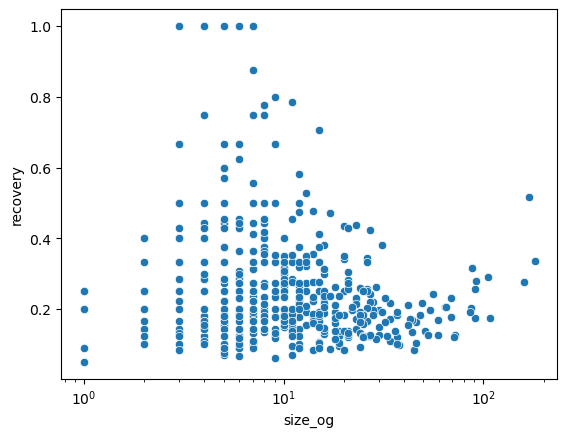

In [75]:
rec_size_df = pd.concat([size_per_module_subset, size_per_module_og, recovery_per_module, relevance_per_module], axis=1)
rec_size_df.columns = ['size_subset', 'size_og', 'recovery', 'relevance']
rec_size_df.head()
# TODO double check if this is the right way around
sns.scatterplot(data=rec_size_df, x='size_og', y='recovery')
plt.xscale('log')

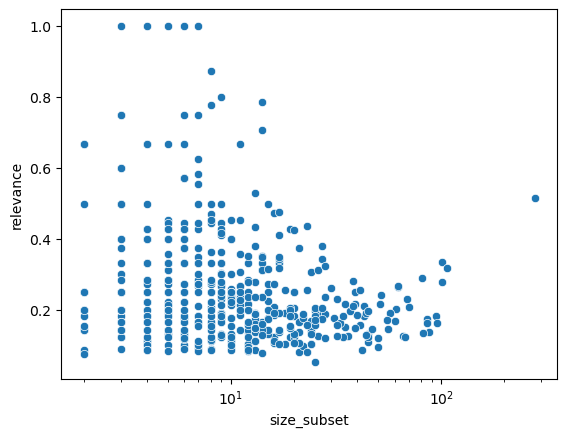

In [76]:
sns.scatterplot(data=rec_size_df, x='size_subset', y='relevance')
plt.xscale('log')

<Axes: ylabel='Count'>

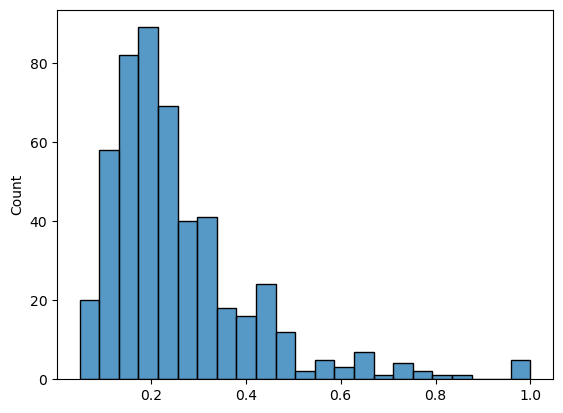

In [58]:
sns.histplot(out_df.max(axis=0))

<Axes: ylabel='Count'>

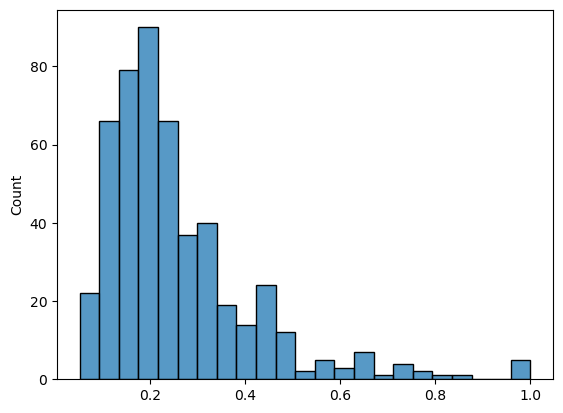

In [57]:
sns.histplot(out_df.max(axis=1))

In [ ]:
# Some debugging. Step one look at the size of the dataframes, then of the clusters, then at the dependence on the nr of modules, then at the jackknife size?

def debug_func():
    dists = {'local': local_dist_path,
             'summed': summed_dist_path,
             'atted': atted_dist_path}
    cluster_list = []
    for dist_name, in_path in dists.items():
        print(in_path)
        if in_path.name.endswith('.pkl'):
            with open(in_path, 'rb') as f:
                in_dist_df = pickle.load(f)
        elif in_path.name.endswith('.parquet.gzip'):
            in_dist_df = pd.read_parquet(in_path)
            # Ensure columns are gene names as well
            if in_dist_df.index.dtype == 'int64':
                in_dist_df = in_dist_df.set_index(in_dist_df.columns[0])
                in_dist_df = in_dist_df.max().max() - in_dist_df
                # Make symmetrical
                in_dist_df = pd.DataFrame(squareform(squareform(in_dist_df, checks=False)), index=in_dist_df.index, columns=in_dist_df.columns)
        print(in_dist_df.shape[0])
        shrinkage_size = 10_000 / in_dist_df.shape[0]
        # TODO ensure same genes?
        in_dist_df = random_subset_of_df(in_dist_df, shrinkage_size)
        print(in_dist_df.shape[0])
        clusters = from_dist_df_to_clustering(in_dist_df)
        clusters['method'] = dist_name
        cluster_list.append(clusters)
        
        # sns.histplot(clusters['cluster_id'].value_counts())
        # plt.legend(['local', 'summed', 'atted'])
        # plt.xlabel('size')
        # plt.show()

    return cluster_list

clusters_list = debug_func()
all_things = pd.concat(clusters_list)
all_things.groupby('method').apply(lambda x: x['cluster_id'].value_counts().median())

In [ ]:
og_df.shape
test_df.shape

In [ ]:
with open(local_dist_path, 'rb') as f:
    in_dist_df = pickle.load(f)
og_df = from_dist_df_to_clustering(in_dist_df)

In [ ]:
og_df.head()

In [ ]:
copied_df = copy.deepcopy(og_df)
copied_df.index = np.random.permutation(og_df.index)
copied_df.head()

In [ ]:
test_df = all_things[all_things['method']=='local'].drop('method', axis=1)
test_df.head()

In [ ]:
one_group_df = test_df[test_df['cluster_id']==83]
one_group_df

In [ ]:
# get same genes in og_df
merged_df = one_group_df.join(og_df, how='inner', lsuffix='_subset', rsuffix='_og')
# Extract extra genes from og_df that are in one of the clusters
extra_genes = og_df[og_df['cluster_id'].isin(merged_df['cluster_id_og'])]
# Add them as well
extra_genes_df = og_df.loc[extra_genes.index.tolist(), :]
extra_genes_df = extra_genes_df.join(test_df, how='left', lsuffix='_og', rsuffix='_subset')
extra_genes_df = extra_genes.dropna()
ari = adjusted_rand_score(extra_genes_df['cluster_id_subset'],
                              extra_genes_df['cluster_id_og'])
print(ari)

In [ ]:
def pairwise_ari_compare_subset_cluster_to_og(og_df, full_local_df):
    def do_one_group(one_group_df):
        # get same genes in og_df
        merged_df = one_group_df.join(og_df, how='inner', lsuffix='_subset', rsuffix='_og')
        # Extract extra genes from og_df that are in one of the clusters
        extra_genes = og_df[og_df['cluster_id'].isin(merged_df['cluster_id_og'])]
        # Add them as well
        extra_genes_df = og_df.loc[extra_genes.index.tolist(), :]
        extra_genes_df = extra_genes_df.join(test_df, how='left', lsuffix='_og', rsuffix='_subset')
        extra_genes_df = extra_genes.dropna()
        ari = adjusted_rand_score(extra_genes_df['cluster_id_subset'],
                                      extra_genes_df['cluster_id_og'])
        return ari
    return full_local_df.groupby('cluster_id').apply(do_one_group)

def debug_test():
    with open(local_dist_path, 'rb') as f:
        in_dist_df = pickle.load(f)
    og_df = from_dist_df_to_clustering(in_dist_df)
    
    test_df = all_things[all_things['method']=='local'].drop('method', axis=1)
    test_df.head()
    pairwise_ari_compare_subset_cluster_to_og(og_df, test_df)
    

## Normal

In [88]:
filter_list = input_parser(summed_dist_path).index.tolist()

In [97]:
atted_scores = wrapper(atted_dist_path, n_repeats=30, filter_list=filter_list)

18957
13861
0.25206149712596787
0.24510309458773805
0.26358566146807993
0.261108652671729
0.24980695953855853
0.25599181034387913
0.27436382028508316
0.25843817288992593
0.27136934545119973
0.25916309592681136
0.279462263555945
0.2668601611125599
0.26925144346188173
0.25361915986864053
0.24589849988885082
0.2537284160157221
0.25611884114423156
0.242466039509803
0.2688474116212722
0.2569961932996921
0.25136329883463704
0.2618734409172934
0.26295214984816595
0.27021459649667806
0.2613186360342017
0.25075590996245983
0.25994056829208684
0.2664996106555211
0.27047027064581675
0.26559119668221814


In [98]:
summed_scores = wrapper(summed_dist_path, n_repeats=30, filter_list=filter_list)

13861
13861
0.21949877511564425
0.22018759338780391
0.2449258766339061
0.23069080256877383
0.23594423289661123
0.23212509404344803
0.2337102042359099
0.2375173593090334
0.22762729469021145
0.23369653205922813
0.2104969245180584
0.23724974816914643
0.24191382197633043
0.24200677827076653
0.22941829746211043
0.23244902339160686
0.24365500489247902
0.22217397663022373
0.22666985741643525
0.25215131371869887
0.2345981782274261
0.23980295429875836
0.22644364195457917
0.23296107254204101
0.23063880922745053
0.24165641939462212
0.24567910674836432
0.23306806291942084
0.22583027120951013
0.23587779660011476


In [99]:
local_scores = wrapper(local_dist_path, n_repeats=30, filter_list=filter_list)

14974
13861
0.20726834280047013
0.20772932677009132
0.20131471798563919
0.2185194120223145
0.2039766386240897
0.20807506094693543
0.20501867039173988
0.21423311981122217
0.22181342664919168
0.20966861726284314
0.23073948848667014
0.20685786137665174
0.20647404918641876
0.20988181728369507
0.21769413882446512
0.2116363288087555
0.21402422205557955
0.22488900220092736
0.2061297834237916
0.21958579915078572
0.21111449951835073
0.21656781144985005
0.20559359013487052
0.2039881787800877
0.22738119703113358
0.20445135603863207
0.2108702567461434
0.2025442442138694
0.20800364792312762
0.21499095427056533


<Axes: xlabel='input_dists', ylabel='robustness'>

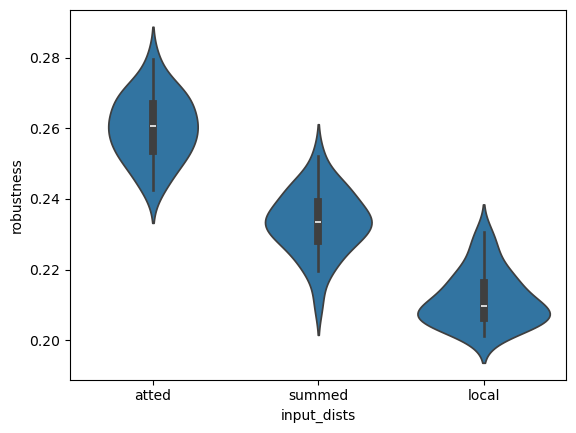

In [100]:
out_df = pd.DataFrame.from_dict({'atted': atted_scores, 'summed': summed_scores, 'local': local_scores})
out_df
out_df = out_df.melt(value_name='robustness', var_name='input_dists')
sns.violinplot(data=out_df, x='input_dists', y='robustness')

In [101]:
# Save to file for download
out_df.to_csv('emtab_robustness_30_jackknifes.csv')

In [ ]:
atted_dist_path